Ujjivan Small Finance Bank Limited (Ujjivan SFB) is a Bengaluru-based **small finance bank focused on advancing financial inclusion by serving financially unserved and underserved segments** across India. Established in 2005 as Ujjivan Financial Services Ltd., an NBFC founded by Samit Ghosh, the institution received RBI approval to operate as a Small Finance Bank (SFB) in 2016 and commenced banking operations in February 2017. Over the years, Ujjivan SFB has evolved from a predominantly microfinance institution into a diversified banking franchise. While customer relationships often begin through micro banking, they expand into housing finance, MSME lending, vehicle finance, gold loans, agriculture finance, deposits, and other banking products. As of the [Annual Report 2025–26](https://www.ujjivansfb.bank.in/assets/USFB_Annual_Report_FY_2025_26_80ced81881.pdf), the Bank holds a **gross loan book of ₹40,655 Crores**, with secured assets accounting for 49.4% of the portfolio and group loans comprising 36.1%. Vehicle finance, gold loans, and agri banking have been identified as key growth drivers. On the liabilities side, the Bank's **total deposits stand at ₹45,668 Crores**, with a CASA ratio of 28.6%. In April 2026, the Bank received a response from the RBI regarding its application for voluntary transition to a universal bank.

As of the [Q1 FY2026–27 report](https://www.ujjivansfb.bank.in/assets/Ujjivan_SFB_Q1_FY_27_IR_PPT_9a9ad1434e.pdf) (published on 30 June 2026), the Bank operates a **pan-India network of 814 branches across 347 districts in 26 States and Union Territories**. The Bank's total business is competitively distributed across all four regions — East (21%), West (20%), North (32%), and South (27%) — with each contributing a significant share. Karnataka, Tamil Nadu, and West Bengal are the top three contributors, together accounting for over 35% of the gross loan book. The Bank serves over 10.2 million customers across metro, urban, semi-urban, and rural markets through a combination of physical, assisted, and digital channels. For FY2026–27, the Bank has outlined a distinct strategic outlook for its asset and liability verticals. On the **asset side**, the focus is to <span style="font-family: monospace;">"grow responsibly, deepen individual lending, and continue the graduation of customers into higher-value secured products over time"</span>. On the **liability side**, the priority is to <span style="font-family: monospace;">"improve the quality of deposit franchise, expanding CASA, deepening engagement with existing depositors, and reducing the cost of funds"</span>.


> **AGENDA:** Recommend at least 100 candidate district-level locations for Ujjivan Small Finance Bank's next phase of branch expansion, using only free and publicly available data. 
>The output should be a ranked, tiered, and business-justified set of locations. 
>Recommendations must be limited to new districts where Ujjivan does not currently operate.


We should also align with the growth strategy stated in the Annual Report:

<span style="font-family: monospace;">"Our branch expansion this year is not about coverage alone but about strengthening the distribution infrastructure for both assets and liabilities in markets where we already have presence and customer understanding."</span>

- We used the Ujjivan [Branch Locator API](https://www.ujjivansfb.bank.in/api/location?type=branches) to obtain the list of all branches. As of 5 August 2026, the dataset consists of 838 active branches.
- We mapped the latitude–longitude coordinates of the branches to the [Local Government Directory (2024)](https://bharatlas.com/view/lgd_districts) boundaries to identify their corresponding districts. (An alternative approach would be to map branches using the India PIN Code directory.)

In [1]:
%load_ext autoreload 
%autoreload 2
from pathlib import Path
from joblib import dump,load
import numpy as np, pandas as pd
pd.options.mode.copy_on_write = True
import geopandas as gpd
import warnings ; warnings.simplefilter('ignore')
np.random.seed(20260805)
from IPython.display import display,HTML


TEMP_DIR = Path.home()/"Projects Running/USFB_temp"
TEMP_DIR.mkdir(exist_ok=True)

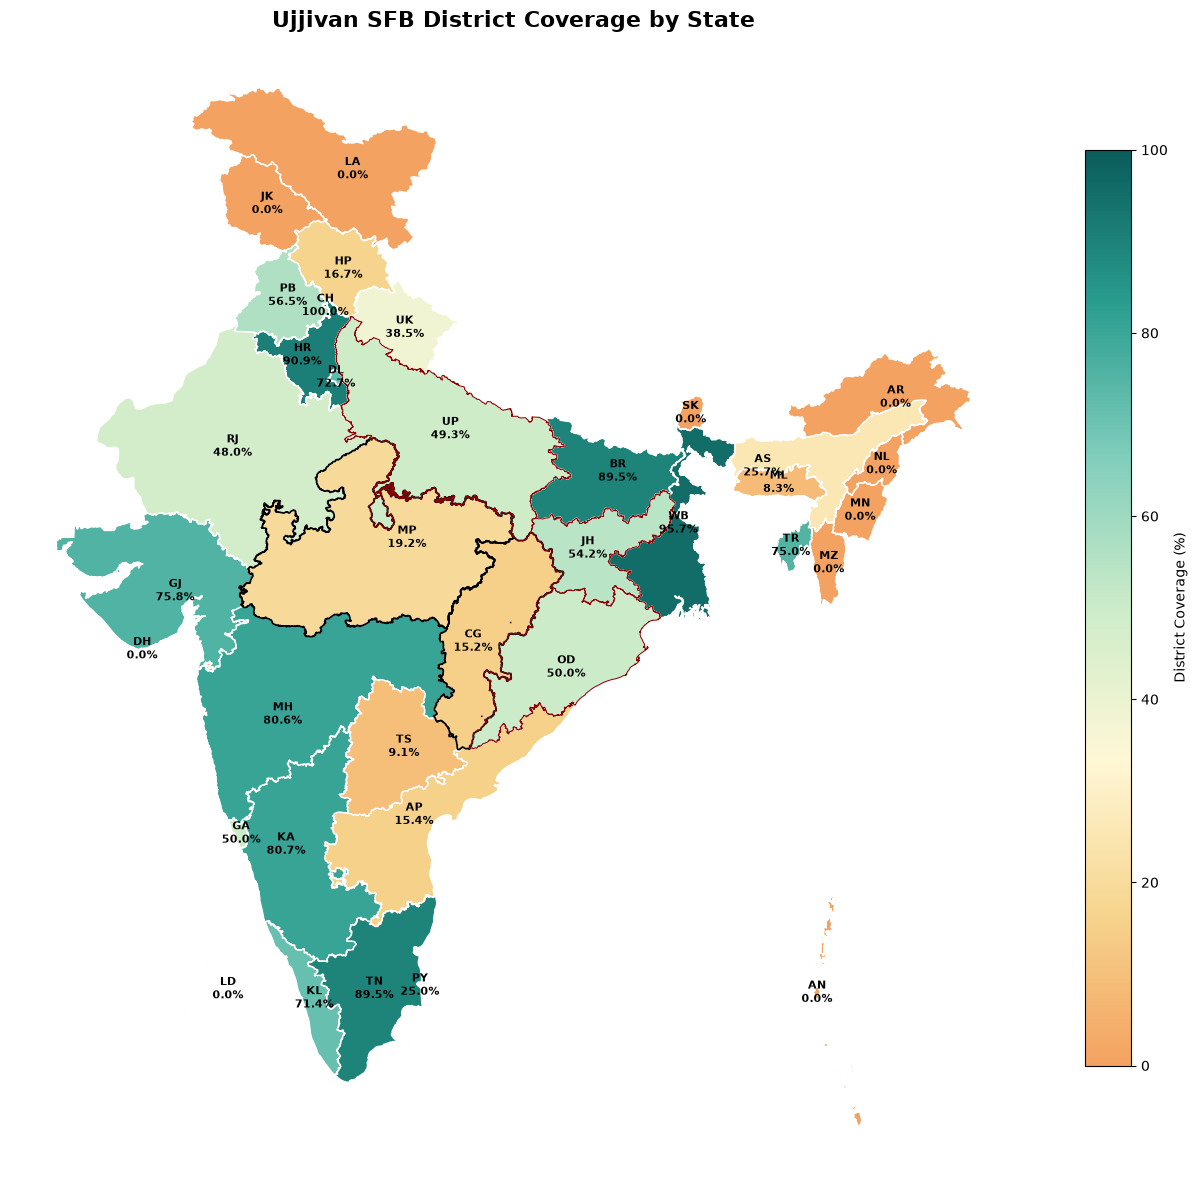

In [2]:
## =======================================
# BRANCH LOCATOR 
## =======================================
"""
BASE = pd.read_csv(
    next(Path("./data/branch locator api").glob("*.csv")),
    header=0, index_col="DocumentID", 
    usecols=["DocumentID","BranchCode","BranchName","Address","Latitude","Longitude"],
    dtype={
        "BranchCode": 'string[pyarrow]',
        "BranchName": 'string[pyarrow]',
        "Address": 'string[pyarrow]',
        "Latitude": 'float64',
        "Longitude": 'float64',
    }
)
for col in ["BranchCode","BranchName","Address"] :
    BASE[col] = BASE[col].str.lower().str.strip()
BASE.info()
#"""
## == ====

## =======================================
# ADMINISTRATIVE BOUNDARIES
## =======================================
"""
ADM = gpd.read_file(
    next(Path("./data/lgd").glob("*.geojson")),
    columns=[
        "dtname","stname","dist_lgd","state_lgd",
        "geometry",
    ],
).set_index(["state_lgd","dist_lgd"]).sort_index()
ADM["dtname"] = ADM["dtname"].str.lower().str.replace(r'[^a-z0-9]+',' ',regex=True).str.replace(r'\s+',' ',regex=True).str.strip().astype('category')
ADM["stname"] = ADM["stname"].str.strip().str.upper().astype('category')
ADM.info()
ADM.to_parquet(TEMP_DIR/'ADM.parquet',index=True,compression='zstd',geometry_encoding='WKB')
#"""
ADM = gpd.read_parquet(TEMP_DIR/'ADM.parquet')
## == ====


## == Spatial Join ====
"""
BRANCH_MASTER = gpd.sjoin(
    gpd.GeoDataFrame(
        BASE,
        geometry=gpd.points_from_xy(
            BASE["Longitude"],BASE["Latitude"],
            crs='EPSG:4326',
        ),
    ),
    ADM,
    how='left',
    predicate='within',
).drop(columns=["Latitude","Longitude","state_lgd","dist_lgd",])

assert BRANCH_MASTER["dtname"].notna().all(), "Some branches could not be mapped to a district."
print(f'''\n Match District : {BRANCH_MASTER["dtname"].notna().mean() * 100:.2f} %''')
BRANCH_MASTER.to_parquet(TEMP_DIR/'BRANCH_MASTER.parquet',index=True,compression='zstd',geometry_encoding='WKB')
#"""
BRANCH_MASTER = gpd.read_parquet(TEMP_DIR/'BRANCH_MASTER.parquet')
## == ====


COVERAGE = (
    ADM
    .dissolve(
        by="stname",
        observed=True,as_index=True,sort=True,
        aggfunc={"dtname": 'nunique'},
    )
    .rename(columns={"dtname": "Total_Districts"})
    .join(
        BRANCH_MASTER
        .groupby("stname",observed=True,as_index=True,sort=False,)
        .agg(
            Covered_Districts=("dtname", "nunique"),
            Existing_Branches=("BranchName", "count"),
        ),
        how='left',
    )
    .fillna(0)
    .astype({
        "Total_Districts": 'int32',
        "Covered_Districts": 'int32',
        "Existing_Branches": 'int32',
    })
)
COVERAGE["Districts_Coverage"] = (100 * COVERAGE["Covered_Districts"]/COVERAGE["Total_Districts"]).round(2)
states_chosen = ["MADHYA PRADESH","CHHATTISGARH",]
states_chosen_2 = ["UTTAR PRADESH","JHARKHAND","ODISHA",]

## -- PLOTTING ----
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt


STATE_ABBR = {
    "ANDAMAN & NICOBAR": "AN",
    "ANDHRA PRADESH": "AP",
    "ARUNACHAL PRADESH": "AR",
    "ASSAM": "AS",
    "BIHAR": "BR",
    "CHANDIGARH": "CH",
    "CHHATTISGARH": "CG",
    "DADRA,NAGAR HAVELI,DAMAN & DIU": "DH",
    "DELHI": "DL",
    "GOA": "GA",
    "GUJARAT": "GJ",
    "HARYANA": "HR",
    "HIMACHAL PRADESH": "HP",
    "JAMMU & KASHMIR": "JK",
    "JHARKHAND": "JH",
    "KARNATAKA": "KA",
    "KERALA": "KL",
    "LADAKH": "LA",
    "LAKSHADWEEP": "LD",
    "MADHYA PRADESH": "MP",
    "MAHARASHTRA": "MH",
    "MANIPUR": "MN",
    "MEGHALAYA": "ML",
    "MIZORAM": "MZ",
    "NAGALAND": "NL",
    "ODISHA": "OD",
    "PUDUCHERRY": "PY",
    "PUNJAB": "PB",
    "RAJASTHAN": "RJ",
    "SIKKIM": "SK",
    "TAMIL NADU": "TN",
    "TELANGANA": "TS",
    "TRIPURA": "TR",
    "UTTAR PRADESH": "UP",
    "UTTARAKHAND": "UK",
    "WEST BENGAL": "WB",
} # ref: https://en.wikipedia.org/wiki/ISO_3166-2:IN


fig, ax = plt.subplots(figsize=(14,12))
ufsb_cmap = LinearSegmentedColormap.from_list(
    "ujjivan",
    [
        "#F4A261",  
        "#F6D58E",  
        "#FFF7D6",  
        "#CDECC9",  
        "#7FCDBB",  
        "#2A9D8F",  
        "#0A5C5A",  
    ],
)

COVERAGE.plot(
    column="Districts_Coverage",
    cmap=ufsb_cmap,
    edgecolor="white",
    linewidth=1,
    legend=True,
    legend_kwds={
        "label": "District Coverage (%)",
        "shrink": 0.8,
    },
    ax=ax,
)
COVERAGE.loc[states_chosen].plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.25,
)
COVERAGE.loc[states_chosen_2].plot(
    ax=ax,
    facecolor="none",
    edgecolor="darkred",
    linewidth=0.75,
)

for state, row in COVERAGE.iterrows():
    x, y = row.geometry.representative_point().coords[0]

    ax.text(
        x,
        y,
        f"{STATE_ABBR.get(state,state)}\n{row['Districts_Coverage']:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black",
    )

ax.set_title(
    "Ujjivan SFB District Coverage by State",
    fontsize=16,
    fontweight="bold",
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## -- ----


Based on the initial screening, we shortlisted **Madhya Pradesh**, and **Chattisgarh** for further analysis. These states exhibit approximately 15-20% district penetration, offering a balance between untapped expansion opportunities and an established market presence. In addition, each shares borders with states where the bank already has relatively high penetration, creating opportunities to leverage existing operational infrastructure, improve network efficiency, and support contiguous branch expansion.

From a data and implementation perspective, these states are also advantageous because their district boundaries have remained largely stable in recent years, avoiding the extensive administrative reorganizations seen in states (such as Andhra Pradesh or Telengana). Furthermore, unlike geographically challenging states (such as Assam or Himachal Pradesh), they do not present significant terrain-related constraints, making them well suited for a robust first-phase district-level analysis.

If time permits, we will analyze **Uttar Pradesh**, **Jharkhand**, and **Odisha** in the next phase. These states have branch coverage in approximately 50% of their districts, making them strong candidates for further expansion analysis. This is particularly relevant given that the East and North regions contribute nearly as much to the Bank's total business as the West and South regions, despite having relatively lower district coverage.

In [3]:
display(HTML(f"""<h2 style="margin-top:0.4em; margin-bottom:0.1em;"><u>Shortlist-1</u></h2>"""))
display(
    COVERAGE.loc[
        states_chosen,
        ["Total_Districts","Covered_Districts","Existing_Branches"],
    ].sort_values("Existing_Branches",ascending=False)
)

display(HTML(f"""<h2 style="margin-top:0.4em; margin-bottom:0.1em;"><u>Shortlist-2</u></h2>"""))
display(
    COVERAGE.loc[
        states_chosen_2,
        ["Total_Districts","Covered_Districts","Existing_Branches"],
    ].sort_values("Existing_Branches",ascending=False)
)


,Total_Districts,Covered_Districts,Existing_Branches
stname,,,
MADHYA PRADESH,52,10,15
CHHATTISGARH,33,5,5


,Total_Districts,Covered_Districts,Existing_Branches
stname,,,
UTTAR PRADESH,75,37,74
ODISHA,30,15,28
JHARKHAND,24,13,23


## **DATA**

The following public datasets were used to support the analysis :

1. [**RBI Spatial Distribution of Deposits and Credit (Statement 4A)**](https://data.rbi.org.in/#/dbie/reports/Publication/Time-Series%20Publications/Annual%20Spatial%20Distribution%20of%20Deposits%20and%20Credit%20-%20%28Including%20Regional%20Rural%20Banks%29/Spatial%20Distribution%20of%20Deposits%20and%20Credit%20-%20%28Including%20Regional%20Rural%20Banks%29) – provides a high-level overview of the banking landscape across districts.
1. [**Census 2011 Primary Census Abstract (PCA SD)**](https://censusindia.gov.in/nada/index.php/catalog/6191) – provides demographic and socioeconomic statistics, including population, households, literacy, and rural-urban distribution.
1. [**Udyam MSME Registration**](https://www.data.gov.in/resource/district-wise-total-msme-registered-enterprises-under-udyam-registration-till-last-date) – provides district-wise counts of registered MSMEs, serving as a proxy for business activity and potential credit demand.

In [4]:
"""
The LGD 2024 district boundaries are treated as the canonical geographic reference. All external datasets are harmonized to this geography before analysis.

DISTRICT MERGERS (source → master)
---------------------------------
    When a single district in the master file corresponds to multiple districts in the source dataset (e.g., recent RBI data containing districts created after the master reference period), 
    the corresponding source districts are aggregated (summed) to populate the master district.

DISTRICT SPLITS (source → master)
---------------------------------
    When multiple districts in the master file correspond to a single district in the source dataset (e.g., Census 2011, which predates the master reference period), 
    the source district values are apportioned among the corresponding master districts using area-based weights.

Note: 
Some of the name reconciliation could be automated using fuzzy matching.
However, fuzzy matching requires threshold tuning and manual verification to avoid incorrect mappings. 
Given the relatively small number of spelling-mismatches (compared to administrative reorganizations), a manually curated lookup table was preferred for transparency and reproducibility.
"""

## == Candidate Districts : all ====
DISTRICT_CANDIDATES = (
    ADM.loc[ADM["stname"].isin(states_chosen)]
    .set_index(["stname","dtname"])
    .sort_index()
) # list of all districts for chosen states
DISTRICT_CANDIDATES["area_km2"] = (
    DISTRICT_CANDIDATES.geometry
    .to_crs('EPSG:7755')
    .area
    / 1e6
) # area of districts (square km)
## == ====



## =======================================
# RBI Statement 4A 
## =======================================
"""
Data_01 = pd.read_excel(
    next(Path("./data/rbi").glob("*.xlsx")),
    skiprows=6,header=0,skipfooter=2,
    usecols="C:G",names=["stname","dtname","reporting_offices","deposit_cr","credit_cr"]
).dropna(subset=["dtname"],ignore_index=True) 
Data_01["dtname"] = Data_01["dtname"].str.lower().str.replace(r'[^a-z0-9]+',' ',regex=True).str.replace(r'\s+',' ',regex=True).str.strip().astype('category')
Data_01["stname"] = Data_01["stname"].str.strip().str.upper().astype('category')
Data_01 = Data_01.set_index(["stname","dtname"]).sort_index()

DISTRICT_CANDIDATES_Data_01 = pd.merge(
    pd.DataFrame(index=DISTRICT_CANDIDATES.index),
    Data_01.loc[states_chosen], 
    left_index=True,right_index=True,
    how='outer',indicator=True,
).fillna(0)
DISTRICT_CANDIDATES_Data_01.loc[DISTRICT_CANDIDATES_Data_01["_merge"] != 'both']
lookup = {
    ('CHHATTISGARH', 'baloda bazar'): [('CHHATTISGARH', 'balodabazar'), ],
    ('CHHATTISGARH', 'dantewada'): [('CHHATTISGARH', 'dakshin bastar dantewada'), ],
    ('CHHATTISGARH', 'gaurella pendra marwahi'): [('CHHATTISGARH', 'gaurela pendra marwahi'), ],
    ('CHHATTISGARH', 'kabirdham'): [('CHHATTISGARH', 'kabeerdham'), ],
    ('CHHATTISGARH', 'kanker'): [('CHHATTISGARH', 'uttar bastar kanker'), ],
    ('CHHATTISGARH', 'khairgarh chhuikhadan gandai'): [('CHHATTISGARH', 'khairagarh chhuikhadan gandai'), ],
    ('CHHATTISGARH', 'korea'): [('CHHATTISGARH', 'koriya'), ],
    ('CHHATTISGARH', 'manendragarh chirimiri bharatpur'): [('CHHATTISGARH', 'manendragarh chirmiri bharatpur'), ],
    ('MADHYA PRADESH', 'narsinghpur'): [('MADHYA PRADESH', 'narsimhapur'), ],
    ('MADHYA PRADESH', 'khargone'): [
        ('MADHYA PRADESH', 'west nimar'),
    ],
    ('MADHYA PRADESH', 'satna'): [
        ('MADHYA PRADESH', 'satna'), 
        ('MADHYA PRADESH', 'maihar'), 
    ],
    ('MADHYA PRADESH', 'rewa'): [
        ('MADHYA PRADESH', 'rewa'), 
        ('MADHYA PRADESH', 'mauganj'), 
    ],
    ('MADHYA PRADESH', 'chhindwara'): [
        ('MADHYA PRADESH', 'chhindwara'), 
        ('MADHYA PRADESH', 'pandhurna'), 
    ],
}
cols = Data_01.columns
for k,v in lookup.items() :
    DISTRICT_CANDIDATES_Data_01.loc[k,cols] += (
        DISTRICT_CANDIDATES_Data_01.loc[v,cols].sum()
    )
DISTRICT_CANDIDATES_Data_01 = DISTRICT_CANDIDATES_Data_01.loc[DISTRICT_CANDIDATES_Data_01["_merge"] != 'right_only'].drop(columns=["_merge",])
ints = Data_01.select_dtypes(include='integer').columns
DISTRICT_CANDIDATES_Data_01[ints] = DISTRICT_CANDIDATES_Data_01[ints].astype('int32')
#"""
## == ====


## =======================================
# Census Abstruct
## =======================================
"""
census_cols = [
    # Households & Population
    "No_HH", "TOT_P", "TOT_M", "TOT_F", 
    "P_06", "P_SC", "P_ST",

    # Education
    "P_LIT",

    # Workforce
    "TOT_WORK_P", "MAINWORK_P", "MARGWORK_P", "NON_WORK_P",
    "MARGWORK_3_6_P", "MARGWORK_0_3_P",
    "MAIN_CL_P", "MAIN_AL_P", "MAIN_HH_P", "MAIN_OT_P",

] # we retain top level M/F ratio only
Data_02 = pd.read_excel(
    next(Path("./data/census").glob("*.xlsx")),
    skiprows=[1,2,3],header=0,
    usecols=["State","Level","Name","TRU"]+census_cols
)
for col in ["Level","TRU"] : Data_02[col] = Data_02[col].str.lower().str.strip().astype('category')
Data_02 = (
    pd.merge(
        Data_02.loc[
            (Data_02["Level"]=='state') & (Data_02["TRU"]=='total'),
            ["State","Name"]
        ].rename(columns={"Name": "stname"}),
        Data_02.loc[
            (Data_02["Level"]=='district'),
        ].rename(columns={"Name": "dtname"}),
        on="State",how='right',
    ).drop(columns=["State","Level"])
) # map the district names against state name using state id
Data_02["dtname"] = Data_02["dtname"].str.lower().str.replace(r'[^a-z0-9]+',' ',regex=True).str.replace(r'\s+',' ',regex=True).str.strip().astype('category')
Data_02["stname"] = Data_02["stname"].str.strip().str.upper().astype('category')
Data_02 = (
    Data_02
    .pivot(
        columns="TRU",
        index=["stname","dtname"],
        values=census_cols
    )
) # separate columns for rural/urban bifurcation 
Data_02 = (
    Data_02
    .reindex(
        columns=pd.MultiIndex.from_product(
            [census_cols,['total','rural','urban']]
        )
    )
    .sort_index()
)
Data_02.columns = [
    f"{col}_{src}" if src!='total' else col
    for col,src in Data_02.columns
]

DISTRICT_CANDIDATES_Data_02 = pd.merge(
    DISTRICT_CANDIDATES["area_km2"],
    Data_02.loc[states_chosen], 
    left_index=True,right_index=True,
    how='outer',indicator=True,
).fillna(0)
DISTRICT_CANDIDATES_Data_02.loc[DISTRICT_CANDIDATES_Data_02["_merge"] != 'both']
lookup = {
    ('CHHATTISGARH', 'kabirdham'): [('CHHATTISGARH', 'kabeerdham'), ] ,
    ('CHHATTISGARH', 'kanker'): [('CHHATTISGARH', 'uttar bastar kanker'), ],
    ('MADHYA PRADESH', 'east nimar'): [('MADHYA PRADESH', 'khandwa east nimar'), ],
    ('MADHYA PRADESH', 'khargone'): [('MADHYA PRADESH', 'khargone west nimar'), ],
    ('MADHYA PRADESH', 'narsinghpur'): [('MADHYA PRADESH', 'narsimhapur'), ],
    ('MADHYA PRADESH', 'narmadapuram'): [
        ('MADHYA PRADESH', 'hoshangabad'), 
    ],
}
lookup_reverse = {
    ('CHHATTISGARH', 'durg'): (
        [
            ('CHHATTISGARH', 'durg'),
            ('CHHATTISGARH', 'balod'),
            ('CHHATTISGARH', 'bemetara'),
        ],
        np.array([1,1,1,])
    ),
    ('CHHATTISGARH', 'raipur'): ( 
        [
            ('CHHATTISGARH', 'raipur'),
            ('CHHATTISGARH', 'baloda bazar'),
            ('CHHATTISGARH', 'sarangarh bilaigarh'),
            ('CHHATTISGARH', 'gariyaband'),
        ],
        np.array([1,1,2,1,])
    ),
    ('CHHATTISGARH', 'bilaspur'): (
        [
            ('CHHATTISGARH', 'bilaspur'),
            ('CHHATTISGARH', 'gaurella pendra marwahi'),
            ('CHHATTISGARH', 'mungeli'),
        ],
        np.array([1,1,1,])
    ),
    ('CHHATTISGARH', 'surguja'): (
        [
            ('CHHATTISGARH', 'surguja'),
            ('CHHATTISGARH', 'surajpur'),
            ('CHHATTISGARH', 'balrampur'),
        ],
        np.array([1,1,1,])
    ),
    ('CHHATTISGARH', 'bastar'): (
        [
            ('CHHATTISGARH', 'bastar'),
            ('CHHATTISGARH', 'kondagaon'),
        ],
        np.array([1,1,])
    ),
    ('CHHATTISGARH', 'dakshin bastar dantewada'): (
        [
            ('CHHATTISGARH', 'dantewada'),
            ('CHHATTISGARH', 'sukma'),
        ],
        np.array([1,1,])
    ),
    ('CHHATTISGARH', 'janjgir champa'): ( 
        [
            ('CHHATTISGARH', 'janjgir champa'),
            ('CHHATTISGARH', 'sakti'),
        ],
        np.array([1,1,])
    ),
    ('CHHATTISGARH', 'rajnandgaon'): ( 
        [
            ('CHHATTISGARH', 'rajnandgaon'),
            ('CHHATTISGARH', 'mohla manpur ambagarh chouki'),
            ('CHHATTISGARH', 'khairgarh chhuikhadan gandai'),
        ],
        np.array([1,1,1,])
    ),
    ('CHHATTISGARH', 'koriya'): (
        [
            ('CHHATTISGARH', 'korea'),
            ('CHHATTISGARH', 'manendragarh chirimiri bharatpur'),
        ],
        np.array([1,1,])
    ),
    ('CHHATTISGARH', 'raigarh'): (
        [
            ('CHHATTISGARH', 'raigarh'),
            ('CHHATTISGARH', 'sarangarh bilaigarh'),
        ],
        np.array([1,2,])
    ),
    ('MADHYA PRADESH', 'shajapur'): ( 
        [
            ('MADHYA PRADESH', 'shajapur'),
            ('MADHYA PRADESH', 'agar malwa'),
        ],
        np.array([1,1,])
    ),
    ('MADHYA PRADESH', 'tikamgarh'): ( 
        [
            ('MADHYA PRADESH', 'tikamgarh'),
            ('MADHYA PRADESH', 'niwari'),
        ],
        np.array([1,1,])
    ),
}

cols = Data_02.columns
for k,v in lookup.items() :
    DISTRICT_CANDIDATES_Data_02.loc[k,cols] += (
        DISTRICT_CANDIDATES_Data_02.loc[v,cols].sum()
    )
for k,(v,c) in lookup_reverse.items():
    w = DISTRICT_CANDIDATES_Data_02.loc[v,"area_km2"].to_numpy()/c
    w /= w.sum()
    DISTRICT_CANDIDATES_Data_02.loc[v,cols] += (
        w[:,None]*DISTRICT_CANDIDATES_Data_02.loc[k,cols].to_numpy()
    )
DISTRICT_CANDIDATES_Data_02 = DISTRICT_CANDIDATES_Data_02.loc[DISTRICT_CANDIDATES_Data_02["_merge"] != 'right_only'].drop(columns=["_merge","area_km2"])
ints = Data_02.select_dtypes(include='integer').columns
DISTRICT_CANDIDATES_Data_02[ints] = DISTRICT_CANDIDATES_Data_02[ints].astype('int32')
#"""
## == ====


## =======================================
# MSME Reg
## =======================================
"""
Data_03 = pd.read_csv(
    next(Path("./data/udyam").glob("*.csv")),
    header=0,
    usecols=[0,2,4,7],names=["stname","dtname","medium_msme","total_msme"]
) # majority of msme are generally micro, while medium msme contibutes the highest amount
Data_03["dtname"] = Data_03["dtname"].str.lower().str.replace(r'[^a-z0-9]+',' ',regex=True).str.replace(r'\s+',' ',regex=True).str.strip().astype('category')
Data_03["stname"] = Data_03["stname"].str.strip().str.upper().astype('category')
Data_03 = Data_03.set_index(["stname","dtname"]).sort_index()

DISTRICT_CANDIDATES_Data_03 = pd.merge(
    pd.DataFrame(index=DISTRICT_CANDIDATES.index),
    Data_03.loc[states_chosen], 
    left_index=True,right_index=True,
    how='outer',indicator=True,
).fillna(0)
DISTRICT_CANDIDATES_Data_03.loc[DISTRICT_CANDIDATES_Data_03["_merge"] != 'both']
lookup = {
    ('CHHATTISGARH', 'baloda bazar'): [('CHHATTISGARH', 'balod bazar'), ],
    ('CHHATTISGARH', 'gariyaband'): [('CHHATTISGARH', 'gariaband'), ],
    ('CHHATTISGARH', 'rajnandgaon'): [('CHHATTISGARH', 'rajnandagaon'), ],
    ('MADHYA PRADESH', 'narmadapuram'): [
        ('MADHYA PRADESH', 'hoshangabad'),
    ],
    ('MADHYA PRADESH', 'satna'): [
        ('MADHYA PRADESH', 'satna'), 
        ('MADHYA PRADESH', 'maihar'), 
    ],
    ('MADHYA PRADESH', 'rewa'): [
        ('MADHYA PRADESH', 'rewa'), 
        ('MADHYA PRADESH', 'mauganj'), 
    ],
    ('MADHYA PRADESH', 'chhindwara'): [
        ('MADHYA PRADESH', 'chhindwara'), 
        ('MADHYA PRADESH', 'pandhurna'), 
    ],
}
cols = Data_03.columns
for k,v in lookup.items() :
    DISTRICT_CANDIDATES_Data_03.loc[k,cols] += (
        DISTRICT_CANDIDATES_Data_03.loc[v,cols].sum()
    )
DISTRICT_CANDIDATES_Data_03 = DISTRICT_CANDIDATES_Data_03.loc[DISTRICT_CANDIDATES_Data_03["_merge"] != 'right_only'].drop(columns=["_merge",])
ints = Data_03.select_dtypes(include='integer').columns
DISTRICT_CANDIDATES_Data_03[ints] = DISTRICT_CANDIDATES_Data_03[ints].astype('int32')
#"""
## == ====



## == Candidate Districts : exclude existing ====
"""
DISTRICT_CANDIDATES_onlyNew = (
    pd.merge(
        pd.concat(
            [
                DISTRICT_CANDIDATES,
                DISTRICT_CANDIDATES_Data_01,
                DISTRICT_CANDIDATES_Data_02,
                DISTRICT_CANDIDATES_Data_03,
            ],
            axis=1,ignore_index=False,
        ),
        BRANCH_MASTER[["stname","dtname"]].set_index(["stname","dtname"]),
        left_index=True,right_index=True,
        how='left',
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge") 
    .sort_index()   
)
DISTRICT_CANDIDATES_onlyNew.to_parquet(TEMP_DIR/'DISTRICT_CANDIDATES_onlyNew.parquet',index=True,compression='zstd',geometry_encoding='WKB')
#"""
DISTRICT_CANDIDATES_onlyNew = gpd.read_parquet(TEMP_DIR/'DISTRICT_CANDIDATES_onlyNew.parquet')
DISTRICT_CANDIDATES_onlyNew.info()
## == ====


<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 70 entries, ('CHHATTISGARH', 'balod') to ('MADHYA PRADESH', 'vidisha')
Data columns (total 61 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   geometry              70 non-null     geometry
 1   area_km2              70 non-null     float64 
 2   reporting_offices     70 non-null     int32   
 3   deposit_cr            70 non-null     float64 
 4   credit_cr             70 non-null     float64 
 5   No_HH                 70 non-null     int32   
 6   No_HH_rural           70 non-null     int32   
 7   No_HH_urban           70 non-null     int32   
 8   TOT_P                 70 non-null     int32   
 9   TOT_P_rural           70 non-null     int32   
 10  TOT_P_urban           70 non-null     int32   
 11  TOT_M                 70 non-null     int32   
 12  TOT_M_rural           70 non-null     int32   
 13  TOT_M_urban           70 non-null     int32   
 14  T